Лычаный НА N33471

Задача 2 "Экономические города"

Импортируем библиотеки.

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline

Маунтим Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Открываем датасет из гугл диска

In [3]:
df = pd.read_csv('/content/drive/MyDrive/itmo/3/теория алгоритмов/lab_1/Econom_Cities_data.csv', sep=";", index_col='City', decimal=',')
df.head()

,Work,Price,Salary
City,,,
Amsterdam,1714,65.6,49.0
Athens,1792,53.8,30.4
Bogota,2152,37.9,11.5
Bombay,2052,30.3,5.3
Brussels,1708,73.8,50.5


Размаунтим Google Drive

In [4]:
drive.flush_and_unmount()

In [5]:
df

,Work,Price,Salary
City,,,
Amsterdam,1714,65.6,49.0
Athens,1792,53.8,30.4
Bogota,2152,37.9,11.5
Bombay,2052,30.3,5.3
Brussels,1708,73.8,50.5
Buenos_Aires,1971,56.1,12.5
Cairo,-9999,37.1,-9999.0
Caracas,2041,61.0,10.9
Chicago,1924,73.9,61.9


Наблюдаем выбросы с значениями -9999, они будут мешать анализу данных, поэтому просто удалим их

In [6]:
df.drop(df.index[[6,17]],inplace = True)

Стандартизируем данные

In [7]:
from sklearn import preprocessing

In [8]:
stand_1 = preprocessing.StandardScaler()
stand_1.fit(df)
X = stand_1.transform(df)
X = pd.DataFrame(X, index=df.index, columns=df.columns)

Посмотрим на данные после применения стандартизации

In [9]:
X.head()

,Work,Price,Salary
City,,,
Amsterdam,-0.962166,-0.212712,0.386095
Athens,-0.509827,-0.770489,-0.373488
Bogota,1.577891,-1.522069,-1.145323
Bombay,0.997969,-1.881316,-1.398517
Brussels,-0.996961,0.174896,0.447351


Проводим иерархический кластерный анализ функцией linkage.

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
link = linkage(X, 'ward', 'euclidean')

In [11]:
print(type(link))
print(link.shape)

<class 'numpy.ndarray'>
(45, 4)


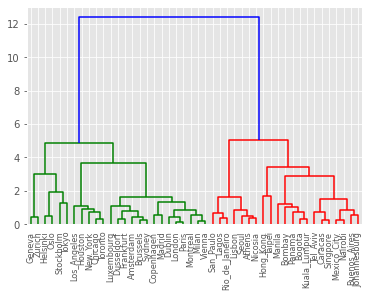

In [12]:
dn = dendrogram(link,labels = X.index.tolist())

Автоматический метод построения дендограммы указывает на три кластера, но на расстоянии ~1 единиц есть еще  деление. Поэтому используем это

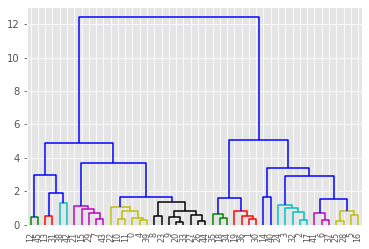

In [13]:
dn = dendrogram(link, color_threshold = 1.5)

Слишком много делений для нас

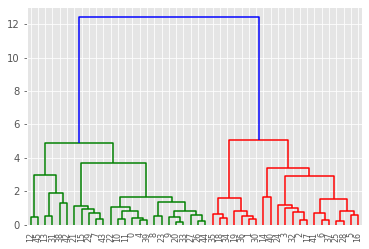

In [14]:
dn = dendrogram(link, color_threshold = 5.5)

Добавим к таблице данных столбец cluster, в который укажем номер кластера, куда попал объект


In [15]:
df['cluster'] = fcluster(link, 5.5, criterion='distance')

In [16]:
print(df)

                Work  Price  Salary  cluster
City                                        
Amsterdam       1714   65.6    49.0        1
Athens          1792   53.8    30.4        2
Bogota          2152   37.9    11.5        2
Bombay          2052   30.3     5.3        2
Brussels        1708   73.8    50.5        1
Buenos_Aires    1971   56.1    12.5        2
Caracas         2041   61.0    10.9        2
Chicago         1924   73.9    61.9        1
Copenhagen      1717   91.3    62.9        1
Dublin          1759   76.0    41.4        1
Dusseldorf      1693   78.5    60.2        1
Frankfurt       1650   74.5    60.4        1
Geneva          1880   95.9    90.3        1
Helsinki        1667  113.6    66.6        1
Hong_Kong       2375   63.8    27.8        2
Houston         1978   71.9    46.3        1
Johannesburg    1945   51.1    24.0        2
Kuala_Lumpur    2167   43.5     9.9        2
Lagos           1786   45.2     2.7        2
Lisbon          1742   56.2    18.8        2
London    

Используя функцию groupby().size подсчитаем кол-во наблюдений попавших в кластеры.

In [17]:
df.groupby('cluster').size()

cluster
1    25
2    21
dtype: int64

Аналогично используя функцию groupby().mean подсчитываем средние значения характеристик в каждом кластере.

In [18]:
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
1,1789.240000,84.972000,59.032000
2,1987.857143,52.395238,16.347619


Изученные нами кластеры достатчно сильно отличаются в средних значениях. 

*   Кластер 1 - работают по времени меньше, выше в 3,5 раза зарплата, но цена высокая 
*  Кластер 2 - работают больше, цены меньше, но зарплата очень низкая

In [19]:
df[df['cluster']==1].index.values

array(['Amsterdam', 'Brussels', 'Chicago', 'Copenhagen', 'Dublin',
       'Dusseldorf', 'Frankfurt', 'Geneva', 'Helsinki', 'Houston',
       'London', 'Los_Angeles', 'Luxembourg', 'Madrid', 'Milan',
       'Montreal', 'New_York', 'Oslo', 'Paris', 'Stockholm', 'Sydney',
       'Tokyo', 'Toronto', 'Vienna', 'Zurich'], dtype=object)

In [20]:
df[df['cluster']==2].index.values

array(['Athens', 'Bogota', 'Bombay', 'Buenos_Aires', 'Caracas',
       'Hong_Kong', 'Johannesburg', 'Kuala_Lumpur', 'Lagos', 'Lisbon',
       'Manila', 'Mexico_City', 'Nairobi', 'Nicosia', 'Panama',
       'Rio_de_Janeiro', 'San_Paulo', 'Seoul', 'Singpore', 'Taipei',
       'Tel_Aviv'], dtype=object)

In [21]:
df['cluster'].sort_values()

City
Amsterdam         1
Toronto           1
Tokyo             1
Sydney            1
Stockholm         1
Paris             1
Oslo              1
New_York          1
Montreal          1
Milan             1
Madrid            1
Vienna            1
Los_Angeles       1
London            1
Houston           1
Luxembourg        1
Zurich            1
Chicago           1
Helsinki          1
Geneva            1
Frankfurt         1
Dusseldorf        1
Brussels          1
Copenhagen        1
Dublin            1
Seoul             2
Singpore          2
Taipei            2
San_Paulo         2
Tel_Aviv          2
Bogota            2
Athens            2
Bombay            2
Rio_de_Janeiro    2
Johannesburg      2
Panama            2
Caracas           2
Hong_Kong         2
Nairobi           2
Mexico_City       2
Manila            2
Lisbon            2
Lagos             2
Kuala_Lumpur      2
Buenos_Aires      2
Nicosia           2
Name: cluster, dtype: int32

Вывод: можно отметить, что в первом кластере большая часть Европы, мировых столиц, а во втором кластере - менее крупные города, где экономическая ситуация хуже